# Drive noise induced phase decoherence validation

### Author: Daniel Gonçalves Benvenutti - UNICAMP
30 May 2025

Qutip Version: 5.1.1





In [1]:
# to use in google colab
!pip install qutip

In [1]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import lsim, TransferFunction
import functools
from datetime import datetime

## Noise generator functions from [stackoverflow](https://stackoverflow.com/questions/67085963/generate-colors-of-noise-in-python).

In [2]:
def noise_psd(tlist, psd = lambda f: 1):
    N=len(tlist)
    X_white = np.fft.rfft(np.random.randn(N));
    S = psd( np.fft.rfftfreq(N, d=tlist[1]-tlist[0]) )
    # Normalize S
    S = S / np.sqrt(np.mean(S**2))
    X_shaped = X_white * S;
    return np.fft.irfft(X_shaped, n=N);

def PSDGenerator(f):
    return lambda N: noise_psd(N, f)

@PSDGenerator
def white_noise(f):
    return 1;

@PSDGenerator
def blue_noise(f):
    return np.sqrt(f);

@PSDGenerator
def violet_noise(f):
    return f;

@PSDGenerator
def brownian_noise(f):
    return 1/np.where(f == 0, float('inf'), f)

@PSDGenerator
def pink_noise(f):
    return 1/np.where(f == 0, float('inf'), np.sqrt(f))

# Filters

In [3]:
def band_stop(tlist, x_t, f0=1,fc=1, n=1):
    # f0 central frequency [GHz]
    # fc bandwidth [GHz]
    # n stages
    
    #Y(s)=H(s)X(s)
    wc=2*np.pi*fc
    w0=2*np.pi*f0

    #multiples numerator and denominator polynomials of the filter transfer function n times
    num,den=[1],[1]
    for _ in range( n):
        num = np.polymul(num, [1, 0, w0**2])
        den = np.polymul(den, [1, wc, w0**2])
    #system H(s)^n 
    tf=TransferFunction(num,den)
    
    #y(t)
    _, y_t, _ = lsim(tf, U=x_t, T=tlist)
    return y_t

def ideal_band_stop(tlist, x_t, f0=1,fc=1, n=1):
    # f0 central frequency [GHz]
    # fc bandwidth [GHz]
    X_s = np.fft.fft(x_t)
    
    # Calculate the corresponding frequencies
    freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
    
    Y_s = np.where( (np.abs(freq)>= f0-fc/2) & (np.abs(freq)<= f0+fc/2) ,0,X_s)
    
    # Normalize H_s
    #H_s = H_s / np.sqrt(np.mean(H_s**2))
    #Y_s = X_s * H_s
    
    return np.fft.ifft(Y_s)


In [5]:
tlist=np.linspace(0,500,int(500*3000/3)) # ns
y=pink_noise(tlist)
drive_data=band_stop(tlist,y,fc=0.5,n=4)

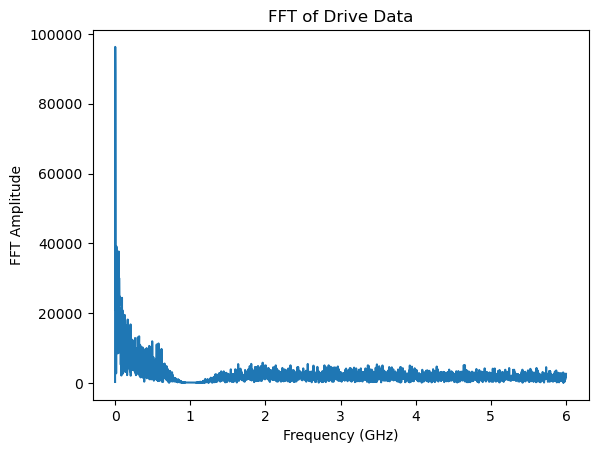

In [6]:
# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=0) & (freq[:middle]<=6))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()

# Simulation

In [27]:
class Noisy_T2:
    

    
    def __init__(self,Det, noise_gen=None, hahn=False):
        
        # operators
        self.sm=qtp.destroy(2)
        self.sx=qtp.sigmax()
        self.sz=qtp.sigmaz()
        self.sy=qtp.sigmay()
        self.n=self.sm.dag()*self.sm
        
        # parameters
        self.wq=3*2*np.pi #qubit resonance frequency [GHz.rad]
        self.Ed=0.01*2*np.pi #driving energy [GHz.rad]
        
        
        self.T1=2000 #relaxation time [ns]
        self.T2=None #dephasing time [ns]
        
  
      
        
        self.Det=Det
        self.noise_gen=noise_gen
        self.hahn=hahn # True if simulation is a Hahn echo and not a Ramsey oscillation
        self.atol=1e-10
        self.rtol=1e-8
    
    
        # initial state
        self.psi0=qtp.basis(2,0)
    
        # initializes with the first pulse        
        self.start()
    
    def start(self):
        # You are supposed to rerun this everytime you change any simulation parameter like T1 or T2 that appears here

        # (T2 must be T2<=2T1)
        if self.T2 is not None and self.T2>2*self.T1:
          raise Exception("T2 must be T2<=2T1")
        
        
        self.qubit_period=2*np.pi/self.wq
        # Times for the free evolution with noise
        self.free_step=self.qubit_period/4 # ns
        self.pulse_step=self.qubit_period/4 # ns
        self.noise_step=self.qubit_period/10 # ns
        
        # time values for the time dependant simulation during excitation
        # The time dependant part of the simulation is usually a bottleneck
        # less points doesn't necessarily means less time/work
        self.pi_pulse=np.pi/self.Ed # [ns]
    
        

    
        # dictionary with simulation options
        # for T2 simulations we need higher numerical precision
        # so we set atol and rtol that limit the (estimated) error
        # per integration step to be smaller
        self.options={"store_final_state":True,"nsteps":10000, "atol":self.atol,"rtol":self.rtol}
    
        # We put here in the init since it's the same for all runs
        # pi/2 pulse simulation with time dependant hamiltonian
        # it just simulates an excitation drive and returns the final state in the res
        self.start_psi, self.start_shift = self.pulse_evolve(self.psi0, 0, self.pi_pulse/2)
    
    def pure_drive(self,t):
        #drive parameters
        wd=(self.wq+self.Det*2*np.pi)/self.wq # [rad.GHz]
        return self.Ed*(np.sin(wd*t)) # [rad.GHz]
        
    # hamiltonian
    def H(self, Ed_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
        # time independant hamiltonian (normalized by wq)
        if Ed_t is None:
            return -0.5*self.wq*self.sz/self.wq
        # time dependant non interpolated drive signal hamiltonian (here Ed_t is a function/lambda)
        if tlist is None:
            return qtp.QobjEvo([-0.5*self.wq*self.sz/self.wq,[self.sx/self.wq,Ed_t]]) 
        # time dependant hamiltonian interpolated drive (here Ed_t is an array with amplitudes)
        # [time independant part, [operator,time dependant operator amplitude]]
        # [qubit, [drive]]
        return qtp.QobjEvo([-0.5*self.wq*self.sz/self.wq,[self.sx/self.wq,Ed_t]],tlist=tlist*self.wq)

    # colapse operators normalized by wq
    def c_ops(self): #T1[ns], T2[ns]
        if self.T2 is None:
            return [np.sqrt(1/self.T1/self.wq)*self.sm]
        gamma_phi=1/self.T2-1/2/self.T1 #pure dephasing constant
        return [np.sqrt(1/self.T1/self.wq)*self.sm,np.sqrt(gamma_phi/2/self.wq)*self.sz]
    #return [np.sqrt(1/T1)*sm,np.sqrt(2*gamma_phi)*n] #same thing for dephasing but in different terms    


    def pulse_evolve(self,psi, shift, period):
        step = self.pulse_step
        t = shift + np.arange( 0, period+step, step ) # [ns]
        res = qtp.mesolve( self.H(self.pure_drive,None), psi, self.wq*t, self.c_ops(), options=self.options )
        # shift to keep the phase consistent
        shift += period
        return res, shift


    
    def free_evolve(self, psi, shift, T):
        t = shift + np.arange(0,T+self.free_step,self.free_step) # [ns]
        noise_data = None
        tlist = None
        if self.noise_gen is not None: #generates noise
            tlist=shift+np.arange(0,T+1,self.noise_step) # [ns]
            noise_data=noise_gen(tlist) # [rad.GHz]
        #Free evolution simulation with(out) noise
        res=qtp.mesolve(self.H(noise_data,tlist), psi ,self.wq*t, self.c_ops(), options=self.options)
        shift += T
        return res,shift
    
    def sequence(self,T):
        # Ramsey/Hahn echo simulation with interrogation time T in [ns] and detuning Det in [GHz]
        
        shift=self.start_shift
        res=self.start_psi
        # for T=0 or smaller than step not to throw an error
        if T>=self.free_step:
           res, shift = self.free_evolve(res.final_state, shift, T)
    
        # additional steps for the Hahn echo procedure
        if self.hahn:
            res, shift = self.pulse_evolve(res.final_state, shift, self.pi_pulse)
            # for T=0 or smaller than step not to throw an error
            if T>=self.free_step:
                  res, shift = self.free_evolve(res.final_state, shift, T)
            
        res, shift = self.pulse_evolve(res.final_state, shift, self.pi_pulse/2)    
        # return excitation expected value of the final state like a measurement
        return qtp.expect(self.n,res.final_state)
        
    def run(self, Tvec, progress='tqdm'):
        try:
            import tqdm
        except ImportError:
            progress=True
        self.Tvec=Tvec
        func = functools.partial(self.sequence)
        self.data=list(qtp.parallel_map(func,Tvec,progress_bar=progress))

    def plot(self, T2_guess=None):
        if self.data is None:
            raise Exception("No data generated")
            return
        if T2_guess is None:
            T2_guess=2*self.T1
        if self.hahn:
            self.echo_plot(self.Tvec, self.data,T2_guess=T2_guess)
        else:
            print(T2_guess)
            self.ramsey_plot(self.Tvec, self.data,T2_guess=T2_guess,Det=self.Det)
        
                           
    def ramsey_plot(self, T,exp, T2_guess=4000, Det=0.002):
        # prompt: plot exp and t as a ramsey oscillation with a damped sine fit
        
        def damped_sine(t, amplitude, frequency, tau, phase, offset):
            return amplitude * np.exp( - t/tau) * np.sin(2 * np.pi * frequency * t + phase) + offset
        fig, axes = plt.subplots(1, 1, figsize=(10,6))
        try:
              params, covariance = curve_fit(damped_sine, T, exp, p0=[0.5, Det, T2_guess, np.pi/2, 0.5])
        except Exception:
              pass
        else:
            amplitude, frequency, decay_constant, phase, offset = params
            t=np.linspace(T[0],T[-1],len(T)*10)
            fitted_exp = damped_sine(t, amplitude, frequency, decay_constant, phase, offset)
            axes.set_title(f'Ramsey Oscillation with Damped Sine Fit $T_2^*$={params[2]*1e-3:.2f}$\mu s$')
            
            axes.plot(t, fitted_exp, label='Damped Sine Fit')
        axes.plot(T, exp, label='Simulated Data')
        axes.set_xlabel('Time (ns)')
        axes.set_ylabel('Excitation expectation value')
        
        axes.legend()
        plt.show()
        
    def echo_plot(self, T, exp, T2_guess=4000):
      # prompt: plot the t2 echo exp with T and an exponential upside down non oscillating fit with the time constant in the title of the graph
        
        fig, axes = plt.subplots(1, 1, figsize=(10, 6))
        def exponential_decay(t, amplitude, decay_constant, offset):
          return amplitude * np.exp(-t / decay_constant) + offset
        try:
            params, covariance = curve_fit(exponential_decay, T, exp, p0=[-1, T2_guess, 0.5])
        except Exception:
            pass
        else:
            amplitude, decay_constant, offset = params
            t_fit = np.linspace(T[0], T[-1], 1000)
            fitted_exp = exponential_decay(t_fit, amplitude, decay_constant, offset)
            axes.plot(t_fit/1000, fitted_exp, label='Exponential Fit')
            axes.set_title(f'T2 Echo with Exponential Fit, $T_2^{{echo}}$={2*decay_constant/1000:.2f}$\mu s$')
        
        axes.plot(T/1000, exp, label='Simulated Data')
        axes.set_xlabel('Time ($\mu $s)')
        axes.set_ylabel('Excitation expectation value')
        axes.legend()
        plt.show()

In [28]:
T=np.linspace(0,4000,32) #ns
def noise_gen(tlist):
    return 2*0.01*2*np.pi*band_stop(tlist,white_noise(tlist),f0=3, fc=0.05,n=3)
exp1=Noisy_T2(0.002,noise_gen=noise_gen)
exp1.run(T)

  0%|          | 0/32 [00:00<?, ?it/s]

4000


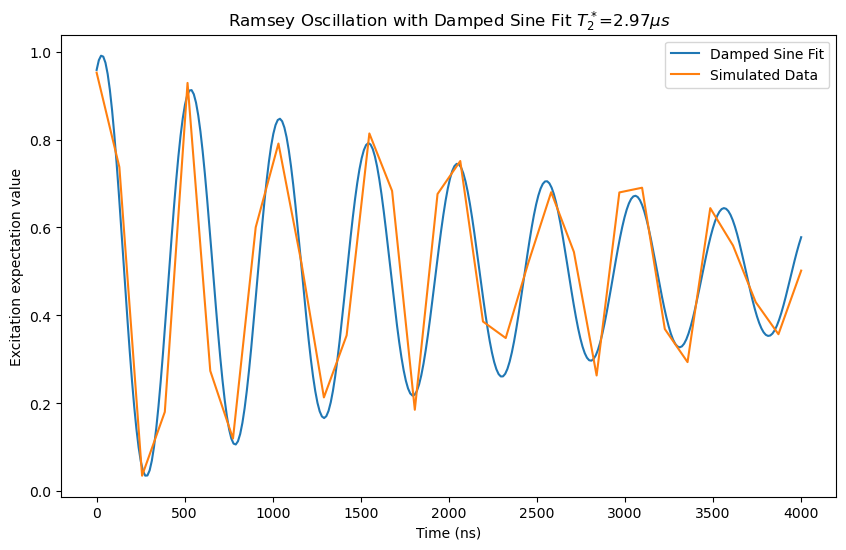

In [29]:
exp1.plot()

In [30]:
T=np.linspace(0,6000,16) #ns
exp1=Noisy_T2(0.0,hahn=True,noise_gen=None)
exp1.run(T)

  0%|          | 0/16 [00:00<?, ?it/s]

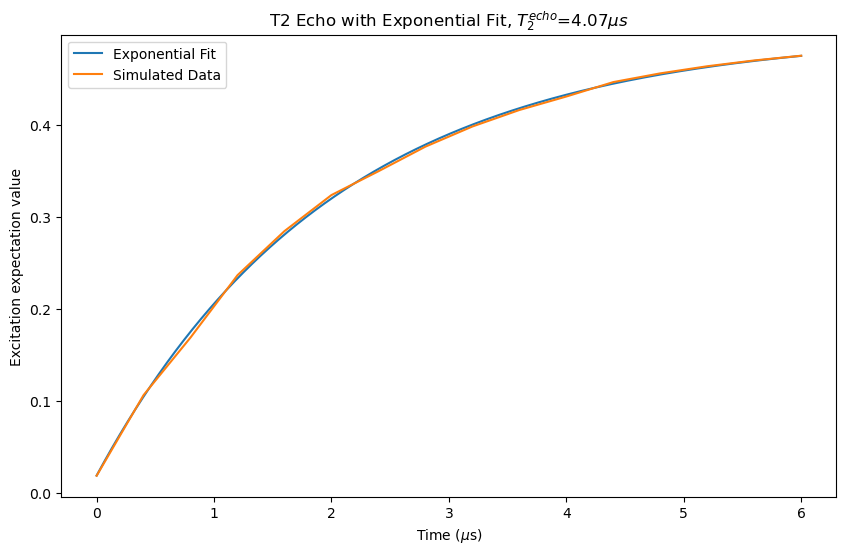

In [31]:
exp1.plot()

In [ ]:
T=np.linspace(0,10000,32) #ns
def noise_gen(tlist):
    return 1*Ed*band_stop(tlist,white_noise(tlist),f0=wq/2/np.pi, fc=0.07,n=3)
exp1=Noisy_T2(0.0,hahn=True,noise_gen=None)
exp1.run(T)

In [ ]:
exp1.plot()

In [52]:
from datetime import datetime


procedure="Ramsey"
Det=0
color="white"
amp=10000
noise_filter="band_stop"
flnm=f"dephasing_data/{procedure}-Det{Det}-{color}-{noise_filter}-{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.npz"
flnm
np.savez(flnm, T=T, data=exp1.data)

In [53]:
data=np.load(f"./{flnm}")

In [54]:
data["T"]

array([   0.,  400.,  800., 1200., 1600., 2000., 2400., 2800., 3200.,
       3600., 4000., 4400., 4800., 5200., 5600., 6000.])